# Aprendizado Supervisionado – Pipeline de Regressão

## Predição de Custos Médicos com Machine Learning

### Autor

André Douglas da Silva Cruz

## Objetivo

O objetivo deste projeto é desenvolver modelos de Aprendizado Supervisionado capazes de prever os custos médicos individuais (`charges`) com base em características demográficas e comportamentais dos pacientes. Para isso, serão aplicadas técnicas de análise exploratória de dados, pré-processamento, engenharia de atributos, modelagem preditiva e avaliação de desempenho.

## Contexto

A previsão de custos médicos é uma importante aplicação de Machine Learning no setor de saúde e seguros. A capacidade de estimar gastos médicos futuros auxilia organizações na tomada de decisão, planejamento financeiro e definição de políticas de risco.

Ao final do projeto, diferentes modelos de regressão serão treinados e comparados por meio de métricas de desempenho, permitindo identificar quais fatores exercem maior influência sobre os custos médicos e qual algoritmo apresenta melhor capacidade preditiva.


# 1. Importação das Bibliotecas




In [21]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização de dados
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.ensemble import RandomForestRegressor

# Métricas
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Configurações
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

import warnings
warnings.filterwarnings("ignore")

# 2. Carregamento da Base de Dados

In [22]:
df = pd.read_csv("custo_medico.csv")

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# 3. Exploração Inicial da Base de Dados

In [23]:
df.shape

(1338, 7)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [25]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [26]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


## Considerações sobre a Base de Dados

A base de dados é composta por 1.338 registros e 7 variáveis, contendo informações demográficas, comportamentais e geográficas dos indivíduos, além dos respectivos custos médicos representados pela variável `charges`.

Em relação aos tipos de dados, foram identificadas 4 variáveis numéricas (`age`, `bmi`, `children` e `charges`) e 3 variáveis categóricas (`sex`, `smoker` e `region`). Essa combinação torna a base adequada para aplicação de técnicas de regressão após a transformação das variáveis categóricas em representações numéricas.

A análise estatística indica que os indivíduos possuem idade média de aproximadamente 39 anos e IMC médio de 30,66. O número médio de dependentes é de 1,09 por pessoa.

Os custos médicos apresentam elevada variabilidade, com média de R$ 13.270,42 e desvio padrão de R$ 12.110,01. Além disso, observa-se uma ampla diferença entre o menor valor registrado (R$ 1.121,87) e o maior custo observado (R$ 63.770,43), sugerindo a presença de indivíduos com gastos significativamente superiores à média da população.

Por fim, a verificação da qualidade dos dados demonstrou que nenhuma das variáveis possui valores ausentes, eliminando a necessidade de tratamentos de imputação e permitindo o avanço para as etapas de análise exploratória e modelagem preditiva.

### Principais Observações Iniciais

- A base apresenta boa qualidade, sem registros incompletos.
- Os custos médicos possuem grande dispersão, indicando um problema de regressão com alta variabilidade.
- A variável `charges` provavelmente não segue uma distribuição normal, devido à grande diferença entre os valores mínimos e máximos observados.
- As variáveis `smoker`, `age` e `bmi` são potenciais candidatas a exercer forte influência sobre os custos médicos, hipótese que será investigada na análise exploratória.

# 4. Análise Exploratória dos Dados (EDA)



## 4.1 Relação entre Idade e Custos Médicos

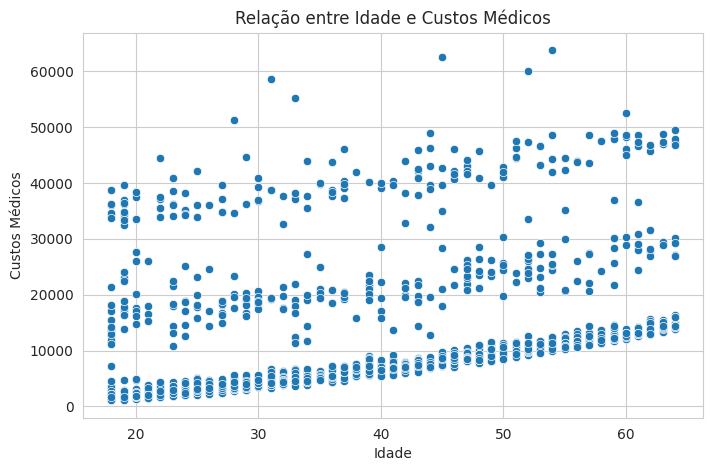

In [27]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='age',
    y='charges'
)

plt.title('Relação entre Idade e Custos Médicos')
plt.xlabel('Idade')
plt.ylabel('Custos Médicos')

plt.show()

## Análise da Relação entre Idade e Custos Médicos

O gráfico de dispersão evidencia uma tendência positiva entre a idade dos indivíduos e os custos médicos. De modo geral, observa-se que os gastos com saúde tendem a aumentar conforme a idade avança, indicando que pacientes mais velhos apresentam maior probabilidade de gerar despesas médicas elevadas.

Além do crescimento dos custos ao longo das faixas etárias, nota-se um aumento da dispersão dos valores para indivíduos mais velhos, sugerindo maior variabilidade nos gastos médicos conforme a idade aumenta.

Outro aspecto relevante é a presença de agrupamentos distintos de observações, indicando que a idade, embora importante, não é o único fator responsável pela variação dos custos. Esse comportamento sugere a influência de outras características presentes na base de dados, que serão investigadas nas próximas análises.

Também foram identificados registros com custos significativamente elevados, ultrapassando R$ 60.000, reforçando a existência de indivíduos com perfis de risco bastante distintos da média observada.

## 4.2 Relação entre IMC e Custos Médicos

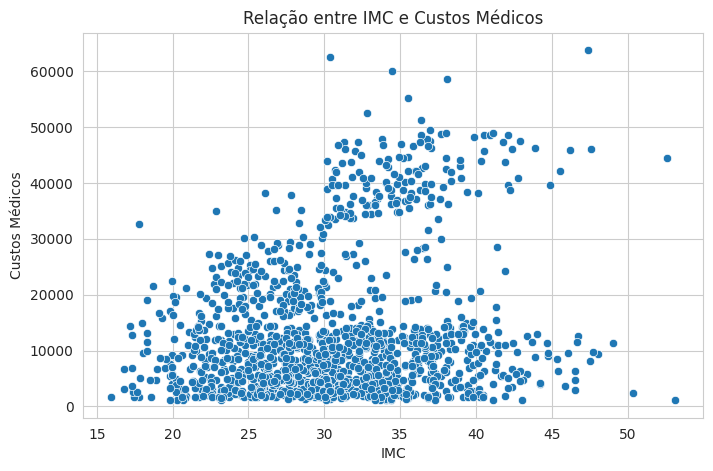

In [28]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='bmi',
    y='charges'
)

plt.title('Relação entre IMC e Custos Médicos')
plt.xlabel('IMC')
plt.ylabel('Custos Médicos')

plt.show()

## Análise da Relação entre IMC e Custos Médicos

O gráfico de dispersão indica uma associação positiva entre o Índice de Massa Corporal (IMC) e os custos médicos. De maneira geral, observa-se que indivíduos com IMC mais elevado tendem a apresentar maiores despesas com saúde.

Entretanto, a relação observada apresenta maior dispersão quando comparada à análise da idade, sugerindo que o IMC, isoladamente, não é suficiente para explicar a variação dos custos médicos.

Outro aspecto relevante é a concentração de indivíduos com custos elevados em faixas de IMC superiores a 30, indicando uma possível associação entre sobrepeso, obesidade e aumento dos gastos médicos.

Além disso, a presença de agrupamentos distintos reforça a hipótese de que outros fatores presentes na base de dados também exercem influência significativa sobre os custos médicos, devendo ser investigados nas análises subsequentes.

## 4.3 Impacto do Tabagismo nos Custos Médicos

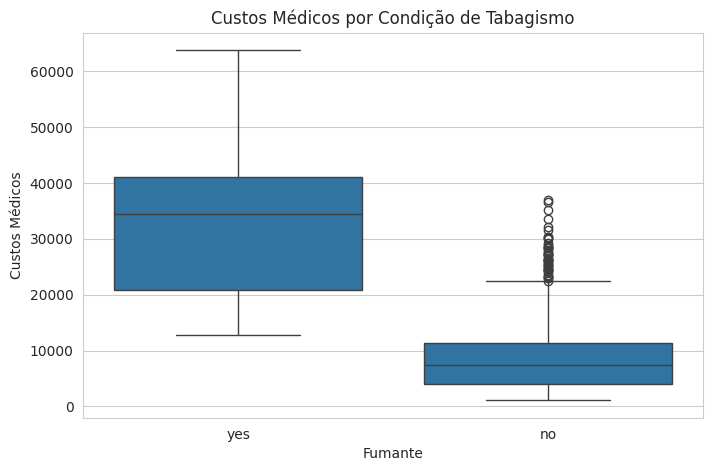

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='smoker',
    y='charges'
)

plt.title('Custos Médicos por Condição de Tabagismo')
plt.xlabel('Fumante')
plt.ylabel('Custos Médicos')

plt.show()

## Impacto do Tabagismo nos Custos Médicos

O boxplot evidencia uma diferença significativa entre os custos médicos de fumantes e não fumantes. Observa-se que os indivíduos fumantes apresentam valores medianos substancialmente superiores, além de uma maior dispersão dos custos quando comparados aos não fumantes.

A separação visual entre os grupos é bastante evidente, indicando que o tabagismo exerce forte influência sobre os gastos médicos. Além disso, os fumantes concentram os maiores valores observados na base de dados, reforçando sua relevância como fator de risco para aumento dos custos com saúde.

Embora existam alguns casos de não fumantes com despesas elevadas, a distribuição geral dos dados demonstra que o hábito de fumar está fortemente associado ao aumento dos custos médicos.

## 4.4 Análise dos Fatores Associados aos Custos Médicos

O tabagismo apresenta forte influência sobre os custos médicos. A análise do boxplot evidencia uma diferença significativa entre fumantes e não fumantes, com os fumantes concentrando valores substancialmente mais elevados e maior variabilidade nos gastos. Esse comportamento indica que o hábito de fumar está fortemente associado ao aumento das despesas médicas.

A idade também demonstra relação positiva com os custos médicos. O gráfico de dispersão indica que, à medida que a idade avança, os gastos com saúde tendem a aumentar, embora exista variação significativa entre os indivíduos. Esse padrão sugere que a idade é um fator relevante, mas não exclusivo, na determinação dos custos médicos.

# 5. Pré-processamento dos Dados



## 5.1 Transformação das Variáveis Categóricas



In [30]:

df_model = pd.get_dummies(
    df,
    columns=['sex', 'smoker', 'region'],
    drop_first=True,
    dtype=int
)

df_model.head()


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


## 5.2 Definição das Variáveis Explicativas e da Variável Alvo



In [31]:
X = df_model.drop(columns='charges')
y = df_model['charges']

## 5.3 Separação dos Dados em Treinamento e Teste



In [32]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

## 5.4 Verificação da Divisão dos Dados



In [33]:
print(f"X_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test : {y_test.shape}")

X_train: (1070, 8)
X_test : (268, 8)
y_train: (1070,)
y_test : (268,)


### Considerações sobre a Divisão dos Dados

A divisão foi realizada corretamente, resultando em 1.070 registros destinados ao treinamento e 268 registros reservados para teste.

O conjunto de variáveis explicativas possui 8 atributos após a aplicação do One-Hot Encoding, enquanto a variável alvo permanece representada pela coluna `charges`.

Essa separação permitirá treinar os modelos em uma parcela da base e avaliar seu desempenho em dados não utilizados durante o treinamento, fornecendo uma estimativa mais confiável da capacidade de generalização.

# 6. Modelagem Preditiva



In [34]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

## 6.1 Regressão Linear Simples



In [35]:
# Seleção da variável idade para o modelo simples
X_train_simple = X_train[['age']]
X_test_simple = X_test[['age']]

# Criação e treinamento do modelo
linear_simple = LinearRegression()

linear_simple.fit(X_train_simple, y_train)

# Previsões no conjunto de teste
pred_linear_simple = linear_simple.predict(X_test_simple)

## 6.2 Regressão Linear Múltipla



In [36]:
# Criação e treinamento do modelo de regressão linear múltipla
linear_multiple = LinearRegression()

linear_multiple.fit(X_train, y_train)

# Previsões no conjunto de teste
pred_linear_multiple = linear_multiple.predict(X_test)

## 6.3 Ridge Regression



In [37]:
# Pipeline com padronização e Ridge Regression
ridge_model = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])

# Treinamento do modelo
ridge_model.fit(X_train, y_train)

# Previsões no conjunto de teste
pred_ridge = ridge_model.predict(X_test)

## 6.4 Random Forest Regressor



In [38]:
# Criação e treinamento do modelo Random Forest
random_forest = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_train, y_train)

# Previsões no conjunto de teste
pred_random_forest = random_forest.predict(X_test)

## 6.5 Modelos Treinados

Ao final desta etapa, foram treinados quatro modelos de regressão:

- Regressão Linear Simples, utilizando apenas a idade;
- Regressão Linear Múltipla, utilizando todas as variáveis disponíveis;
- Ridge Regression, com regularização e padronização dos atributos;
- Random Forest Regressor, capaz de identificar relações não lineares entre as variáveis.

Os modelos serão comparados na próxima etapa por meio das métricas MAE, RMSE e R².

# 7. Avaliação dos Modelos



## 7.1 Métricas de Avaliação

As métricas utilizadas para avaliar o desempenho dos modelos foram:

- **MAE (Mean Absolute Error):** representa o erro médio absoluto entre os valores reais e previstos;
- **RMSE (Root Mean Squared Error):** mede a magnitude dos erros, atribuindo maior peso a previsões muito distantes do valor real;
- **R² (Coeficiente de Determinação):** indica a proporção da variação dos custos médicos explicada pelo modelo.

Para MAE e RMSE, valores menores indicam melhor desempenho. Para R², valores mais próximos de 1 indicam maior capacidade explicativa.

## 7.2 Cálculo das Métricas

In [39]:
def avaliar_modelo(nome_modelo, y_real, y_previsto):

    mae = mean_absolute_error(y_real, y_previsto)

    rmse = np.sqrt(
        mean_squared_error(y_real, y_previsto)
    )

    r2 = r2_score(y_real, y_previsto)

    return {
        'Modelo': nome_modelo,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    }

In [40]:
resultados = pd.DataFrame([

    avaliar_modelo(
        'Regressão Linear Simples',
        y_test,
        pred_linear_simple
    ),

    avaliar_modelo(
        'Regressão Linear Múltipla',
        y_test,
        pred_linear_multiple
    ),

    avaliar_modelo(
        'Ridge Regression',
        y_test,
        pred_ridge
    ),

    avaliar_modelo(
        'Random Forest Regressor',
        y_test,
        pred_random_forest
    )
])

resultados = resultados.sort_values(
    by='R²',
    ascending=False
).reset_index(drop=True)

resultados.round(2)

,Modelo,MAE,RMSE,R²
0,Random Forest Regressor,2559.94,4597.05,0.86
1,Regressão Linear Múltipla,4181.19,5796.28,0.78
2,Ridge Regression,4182.80,5796.98,0.78
3,Regressão Linear Simples,9173.26,11661.22,0.12


## 7.3 Comparação entre Regressão Linear Simples e Múltipla



In [41]:
comparacao_lineares = resultados[
    resultados['Modelo'].isin([
        'Regressão Linear Simples',
        'Regressão Linear Múltipla'
    ])
]

comparacao_lineares.round(2)

,Modelo,MAE,RMSE,R²
1,Regressão Linear Múltipla,4181.19,5796.28,0.78
3,Regressão Linear Simples,9173.26,11661.22,0.12


A Regressão Linear Múltipla apresentou desempenho significativamente superior ao modelo simples. Ao utilizar todas as variáveis disponíveis, o coeficiente de determinação aumentou de 0,12 para 0,78, indicando que o modelo múltiplo conseguiu explicar uma parcela muito maior da variação dos custos médicos.

Além disso, o MAE foi reduzido de 9.173,26 para 4.181,19, enquanto o RMSE caiu de 11.661,22 para 5.796,28. Esses resultados mostram que a idade, isoladamente, não é suficiente para estimar os custos médicos com boa precisão.

A inclusão de variáveis como IMC, número de filhos, sexo, tabagismo e região contribuiu de forma relevante para melhorar a capacidade preditiva do modelo.


## 7.4 Comparação Visual do Desempenho dos Modelos


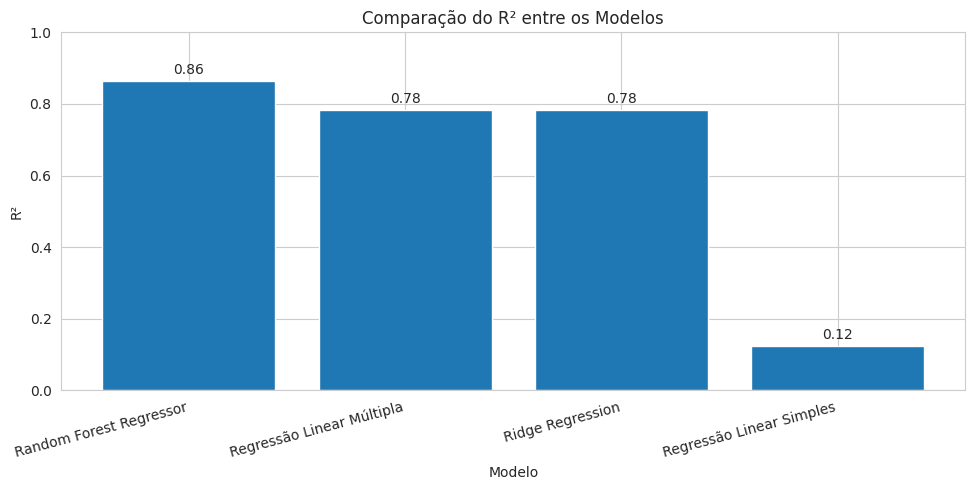

In [42]:
plt.figure(figsize=(10, 5))

barras = plt.bar(
    resultados['Modelo'],
    resultados['R²']
)

plt.title('Comparação do R² entre os Modelos')
plt.xlabel('Modelo')
plt.ylabel('R²')
plt.ylim(0, 1)

for barra, valor in zip(barras, resultados['R²']):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        valor + 0.02,
        f'{valor:.2f}',
        ha='center'
    )

plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

### Análise

O gráfico evidencia que o Random Forest Regressor apresentou o melhor desempenho entre os modelos avaliados, com R² de 0,86. Isso indica que o modelo foi capaz de explicar aproximadamente 86% da variação observada nos custos médicos do conjunto de teste.

A Regressão Linear Múltipla e o Ridge Regression apresentaram desempenho semelhante, ambos com R² de 0,78. Apesar de apresentarem boa capacidade explicativa, ficaram abaixo do Random Forest, que conseguiu capturar melhor relações não lineares e interações entre as variáveis.

A Regressão Linear Simples apresentou R² de apenas 0,12, reforçando que a idade isoladamente não é suficiente para prever os custos médicos com precisão.


# 8. Reflexões e Conclusão Final

## 8.1 Importância das Variáveis no Random Forest

In [43]:
importancias = pd.DataFrame({
    'Variável': X_train.columns,
    'Importância': random_forest.feature_importances_
})

importancias = importancias.sort_values(
    by='Importância',
    ascending=False
).reset_index(drop=True)

importancias.round(4)

,Variável,Importância
0,smoker_yes,0.6100
1,bmi,0.2149
2,age,0.1342
3,children,0.0194
4,sex_male,0.0063
5,region_northwest,0.0057
6,region_southeast,0.0053
7,region_southwest,0.0042


### Análise da Importância das Variáveis

A variável `smoker_yes` apresentou a maior importância no Random Forest, com valor de 0,6100. Isso indica que o tabagismo foi o atributo que mais contribuiu para as previsões de custos médicos realizadas pelo modelo.

Em seguida, destacaram-se as variáveis `bmi` (0,2149) e `age` (0,1342), mostrando que o IMC e a idade também possuem influência relevante na estimativa dos gastos médicos.

As variáveis relacionadas ao número de filhos, sexo e região apresentaram importância reduzida. Portanto, dentro deste modelo, o tabagismo, o IMC e a idade foram os principais fatores associados à previsão dos custos médicos.

É importante ressaltar que a importância das variáveis indica sua contribuição para as previsões do modelo, mas não comprova uma relação causal entre os atributos e os custos médicos.


## 8.2 Reflexões sobre os Resultados

O Random Forest Regressor apresentou o melhor desempenho entre os modelos avaliados, com MAE de 2.559,94, RMSE de 4.597,05 e R² de 0,86. Isso demonstra que o modelo conseguiu explicar aproximadamente 86% da variação dos custos médicos no conjunto de teste.

A análise exploratória e a importância das variáveis no Random Forest indicaram que o tabagismo foi o principal fator associado aos custos médicos. A variável `smoker_yes` apresentou importância de 0,6100, valor consideravelmente superior às demais variáveis, reforçando o padrão observado no boxplot entre fumantes e não fumantes.

Apesar dos bons resultados, o modelo possui limitações. A base contém apenas informações demográficas e comportamentais básicas, não incluindo histórico clínico, diagnóstico de doenças, hábitos alimentares, nível de atividade física ou frequência de utilização de serviços médicos. Além disso, os resultados refletem exclusivamente o conjunto de dados analisado e não devem ser generalizados para outras populações sem validação adicional.


## 8.3 Conclusão Final

Os resultados demonstraram que o tabagismo, o IMC e a idade são fatores relevantes para a previsão dos custos médicos. O Random Forest Regressor apresentou o melhor desempenho, com R² de 0,86 e menor erro entre os modelos avaliados. A comparação entre os modelos mostrou que utilizar múltiplas variáveis melhora significativamente a qualidade das previsões. Apesar disso, a ausência de informações clínicas limita a capacidade de representar todos os fatores associados aos gastos com saúde.
